In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

FOLDER_DATA = "hasil_csv"
FPS_DETEKSI = 60
G_REFERENSI = 9.8

def hitung_presisi(jalur_file):
    try:
        df = pd.read_csv(jalur_file)

        df['Height_cm'] = df['Height_cm']

        t = (df['Frame_Index'] - df['Frame_Index'].iloc[0]) / FPS_DETEKSI

        y = df['Height_cm'] / 100.0

        def model_glbb(t_val, g_val, v0, y0):
            return y0 + v0 * t_val - 0.5 * g_val * t_val ** 2

        popt, _ = curve_fit(model_glbb, t, y)
        g_observasi = abs(popt[0])

        kecepatan_sesaat = -np.gradient(y, t)

        v_maks_terukur = kecepatan_sesaat.max()

        tinggi_total = y.iloc[0] - y.iloc[-1]
        print(f"{y.iloc[0]} dan {y.iloc[-1]}")
        v_maks_teori_ref = np.sqrt(2 * G_REFERENSI * tinggi_total)
        v_maks_teori_obs = np.sqrt(2 * g_observasi * tinggi_total)

        popt, _ = curve_fit(model_glbb, t, y)
        g_observasi = abs(popt[0])
        v0_observasi = popt[1]
        v_teoritis = g_observasi * t - v0_observasi
        return {
            'File': os.path.basename(jalur_file),
            'g_observasi': round(g_observasi, 3),
            'v_maks_terukur': round(v_maks_terukur, 3),
            'v_maks_teori_ref': round(v_maks_teori_ref, 3),
            'v_maks_teori_obs': round(v_maks_teori_obs, 3),
            'tinggi_jatuh_m': round(tinggi_total, 3)
        }, t, y, kecepatan_sesaat, v_teoritis

    except Exception as e:
        print(f"Gagal memproses file {jalur_file}: {e}")
        return None, None, None, None

daftar_file = glob.glob(os.path.join(FOLDER_DATA, "*.csv"))
# print(daftar_file)
ringkasan_hasil = []

print(f"Memulai analisis pada {len(daftar_file)} file...")

for f in daftar_file:

    hasil, t_plot, y_plot, v_plot, v_teori = hitung_presisi(f)

    if hasil:
        ringkasan_hasil.append(hasil)

        plt.figure(figsize=(12, 5))

        # Jarak vs Waktu
        plt.subplot(1, 2, 1)
        plt.scatter(t_plot, y_plot, color='blue', s=30, label='Data (Bulat)')
        plt.title(f"Grafik Jarak vs Waktu\n{hasil['File']}")
        plt.xlabel("Waktu (s)")
        plt.ylabel("Tinggi (m)")
        plt.grid(True)
        plt.legend()

        # Kecepatan vs Waktu
        plt.subplot(1, 2, 2)
        plt.plot(t_plot, v_plot, marker='o', color='red', linestyle='--')
        plt.title(f"Grafik Kecepatan vs Waktu\nV-Maks: {hasil['v_maks_terukur']} m/s")
        plt.xlabel("Waktu (s)")
        plt.ylabel("Kecepatan (m/s)")
        plt.grid(True)

        plt.tight_layout()
        plt.savefig(f"analisis_{hasil['File']}.png")
        plt.close()

if ringkasan_hasil:
    df_ringkasan = pd.DataFrame(ringkasan_hasil)
    df_ringkasan.to_csv("ringkasan_analisis_fisika.csv", index=False)
    print("\n--- TABEL HASIL PERHITUNGAN ---")
    print(df_ringkasan.to_string(index=False))
    print("\nProses selesai. File 'ringkasan_analisis_fisika.csv' telah dibuat.")


Memulai analisis pada 10 file...
1.4880000000000002 dan 0.1033
1.492 dan 0.0412
1.476 dan 0.0688
1.5306 dan 0.0375
1.4848 dan 0.0775
1.4888 dan 0.08380000000000001
1.5282 dan 0.10439999999999999
1.4936 dan 0.08380000000000001
1.5336 dan 0.0412
1.4928 dan 0.09380000000000001

--- TABEL HASIL PERHITUNGAN ---
           File  g_observasi  v_maks_terukur  v_maks_teori_ref  v_maks_teori_obs  tinggi_jatuh_m
    perlima.csv        8.943           4.728             5.210             4.977           1.385
 persepuluh.csv        9.120           4.783             5.333             5.144           1.451
    perenam.csv        9.117           5.469             5.252             5.066           1.407
    persatu.csv        8.944           4.919             5.410             5.168           1.493
persembilan.csv        9.080           4.777             5.252             5.055           1.407
   perempat.csv        9.369           5.553             5.248             5.131           1.405
     perdua.c

In [61]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import glob
import os

FOLDER_DATA = "hasil_csv"
FPS = 60
G_REF = 9.8

def calculate_g_and_v_max(file_path):
    df = pd.read_csv(file_path)

    t = (df['Frame_Index'] - df['Frame_Index'].iloc[0]) / FPS
    y = df['Height_cm'] / 100.0  # Konversi cm ke meter

    def model_glbb(t_val, g_val, v0, y0):
        return y0 + v0 * t_val - 0.5 * g_val * t_val**2

    popt, _ = curve_fit(model_glbb, t, y, p0=[9.8, 0, 1.5])
    g_obj = abs(popt[0])

    v = -np.gradient(y, t)
    v_max = v.max()

    return g_obj, v_max, t, y, v

files = glob.glob(os.path.join(FOLDER_DATA, "*.csv"))
results = []

for f in files:
    g_individu, vmax, t, y, v = calculate_g_and_v_max(f)

    galat_individu = (abs(g_individu - G_REF) / G_REF) * 100

    results.append({
        'Percobaan': os.path.basename(f),
        'g_m/s2': round(g_individu, 3),
        'v_maks_m/s': round(vmax, 3),
        'Galat_%': round(galat_individu, 2)
    })

df_individu = pd.DataFrame(results)

g_array = df_individu['g_m/s2'].values
n = len(g_array)
g_rata = np.mean(g_array)
std_dev = np.std(g_array, ddof=1)
k_absolut = std_dev / np.sqrt(n)
k_relatif = (k_absolut / g_rata) * 100
galat_total = (abs(g_rata - G_REF) / G_REF) * 100

print("--- DATA PER PERCOBAAN ---")
print(df_individu.to_string(index=False))
df_individu.to_csv("hasil_per_percobaan.csv", index=False)

print("\n--- ANALISIS GABUNGAN (STATISTIK) ---")
print(f"Rata-rata g            : {g_rata:.3f} m/s^2")
print(f"Standar Deviasi        : {std_dev:.3f} m/s^2")
print(f"Ketidakpastian Absolut : {k_absolut:.3f} m/s^2")
print(f"Ketidakpastian Relatif : {k_relatif:.2f} %")
print(f"Persentase Galat Total : {galat_total:.2f} %")
print(f"Hasil Akhir            : g = ({g_rata:.2f} +/- {k_absolut:.2f}) m/s^2")
print(f"Ketelitian (Presisi)   : {100 - k_relatif:.2f} %")

hasil_statistik = {
    'Parameter': [
        'Jumlah Percobaan (n)',
        'Rata-rata g (m/s2)',
        'Standar Deviasi',
        'Ketidakpastian Absolut',
        'Ketidakpastian Relatif (%)',
        'Persentase Galat Total (%)',
        'Ketelitian (%)'
    ],
    'Nilai': [
        n, round(g_rata, 3), round(std_dev, 3), round(k_absolut, 3),
        round(k_relatif, 2), round(galat_total, 2), round(100 - k_relatif, 2)
    ]
}

df_statistik = pd.DataFrame(hasil_statistik)
df_statistik.to_csv("ringkasan_statistik.csv", index=False)

--- DATA PER PERCOBAAN ---
      Percobaan  g_m/s2  v_maks_m/s  Galat_%
    perlima.csv   8.943       4.728     8.75
 persepuluh.csv   9.120       4.783     6.94
    perenam.csv   9.117       5.469     6.96
    persatu.csv   8.944       4.919     8.73
persembilan.csv   9.080       4.777     7.35
   perempat.csv   9.369       5.553     4.40
     perdua.csv   9.179       4.912     6.34
    pertiga.csv   8.964       4.708     8.53
 perdelapan.csv   8.968       4.954     8.49
   pertujuh.csv   9.110       4.750     7.04

--- ANALISIS GABUNGAN (STATISTIK) ---
Rata-rata g            : 9.079 m/s^2
Standar Deviasi        : 0.134 m/s^2
Ketidakpastian Absolut : 0.042 m/s^2
Ketidakpastian Relatif : 0.47 %
Persentase Galat Total : 7.35 %
Hasil Akhir            : g = (9.08 +/- 0.04) m/s^2
Ketelitian (Presisi)   : 99.53 %


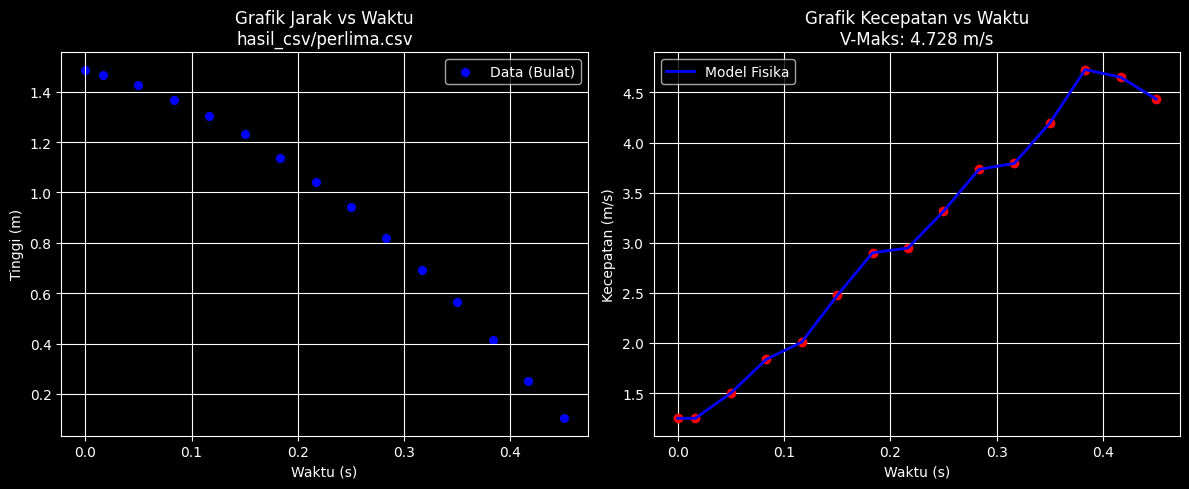

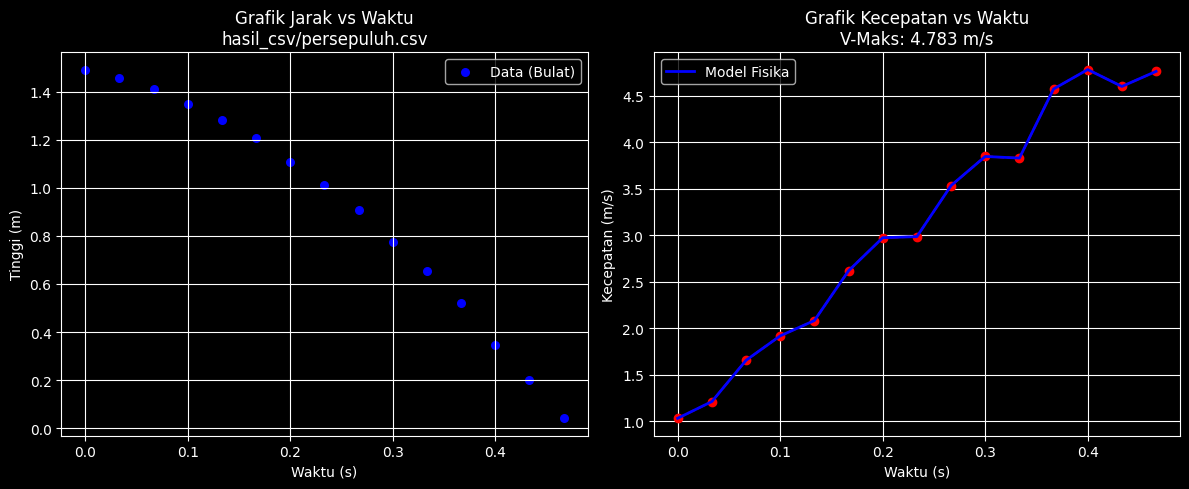

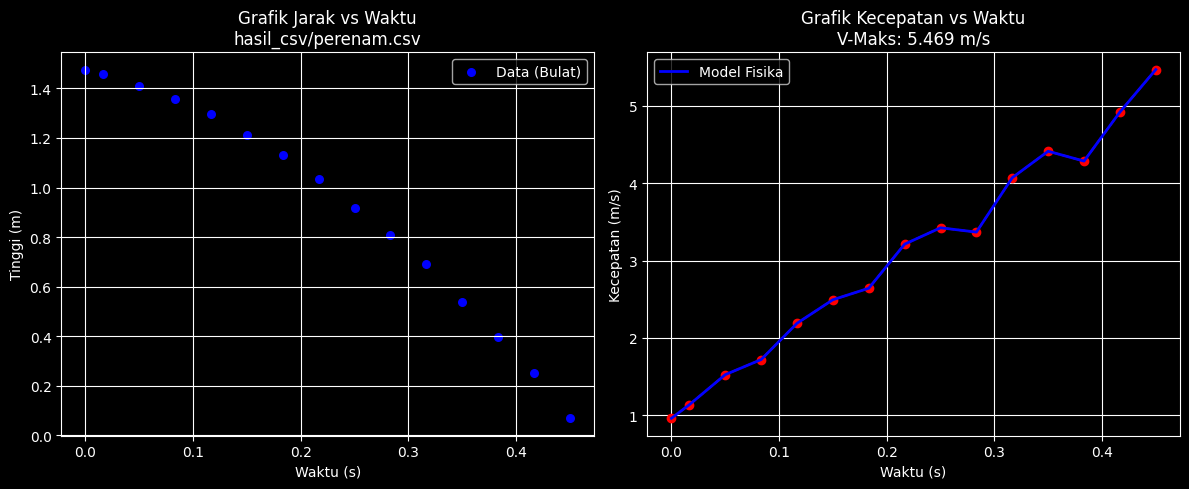

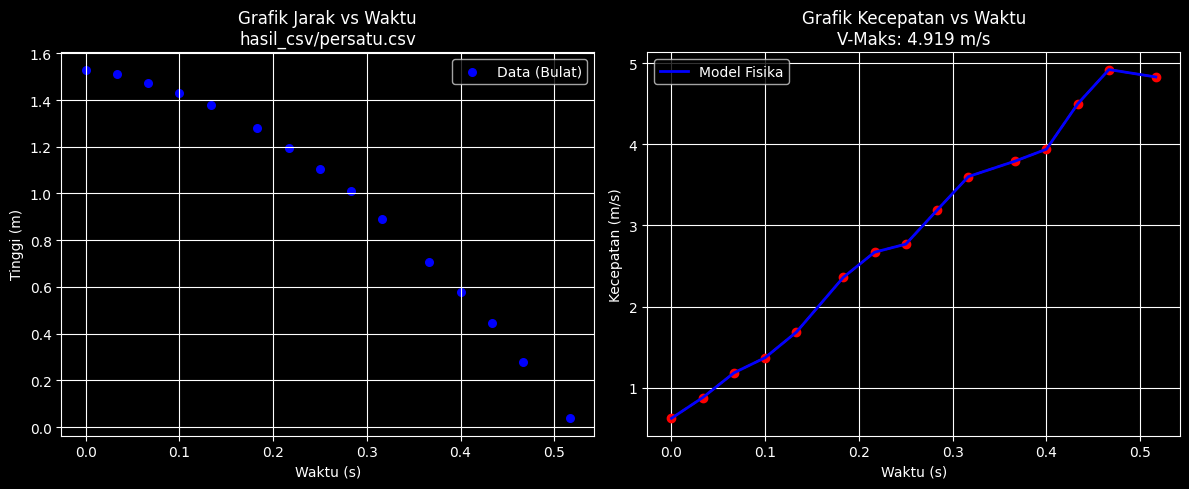

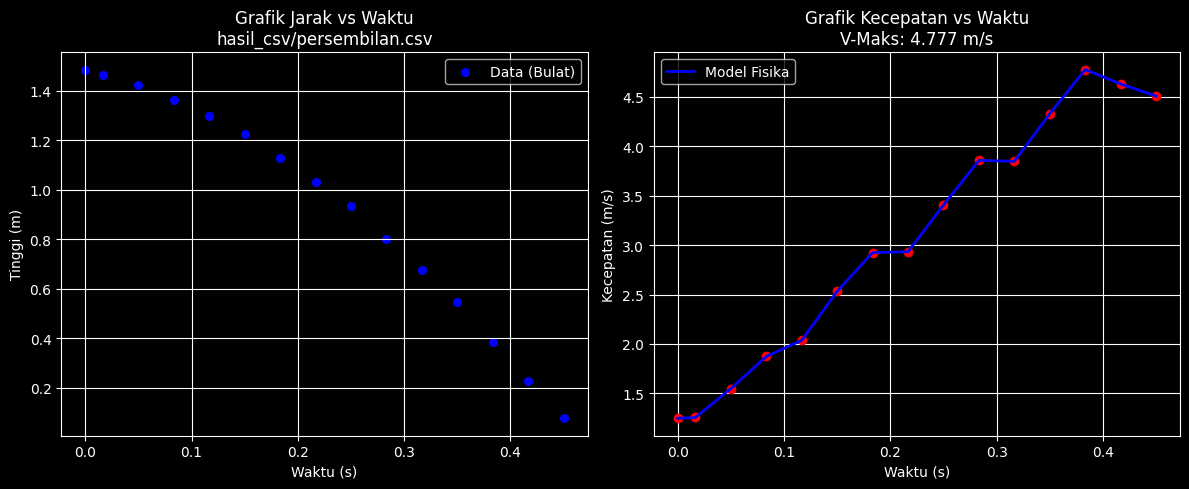

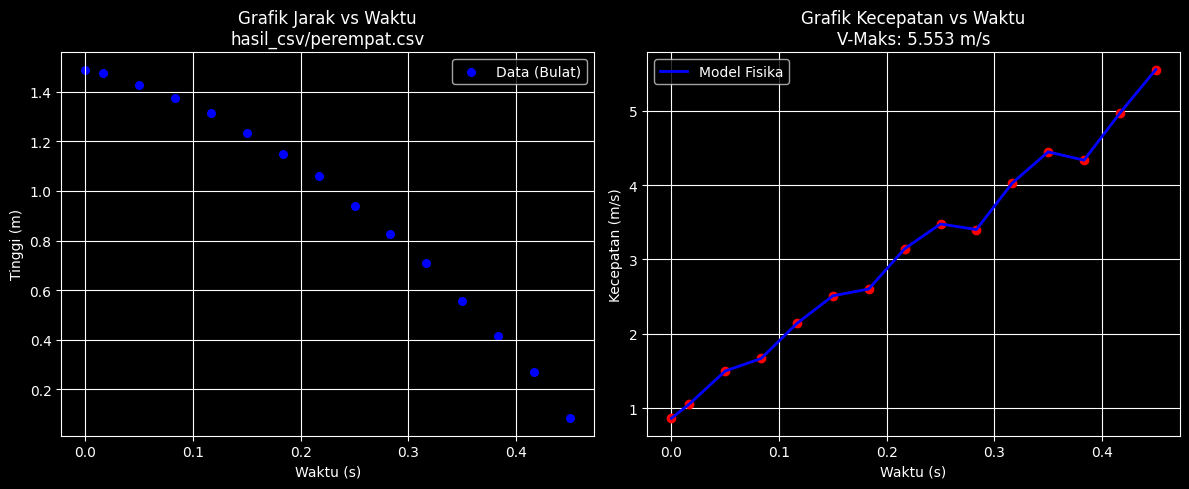

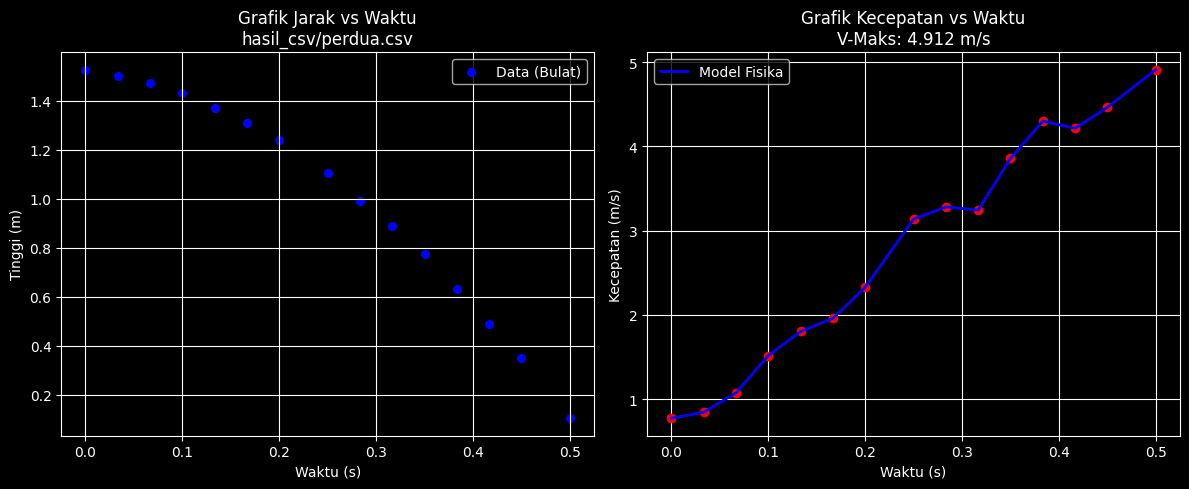

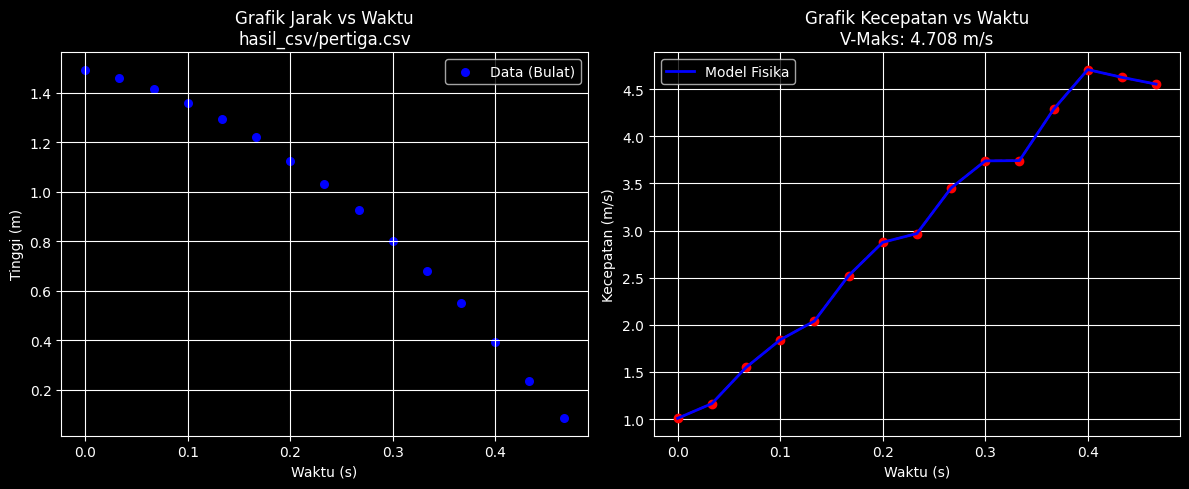

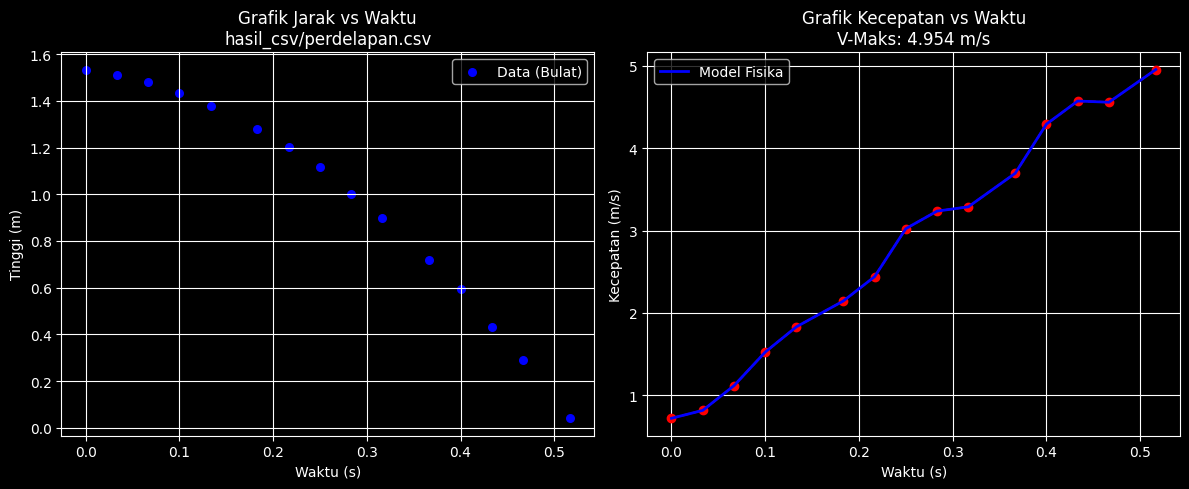

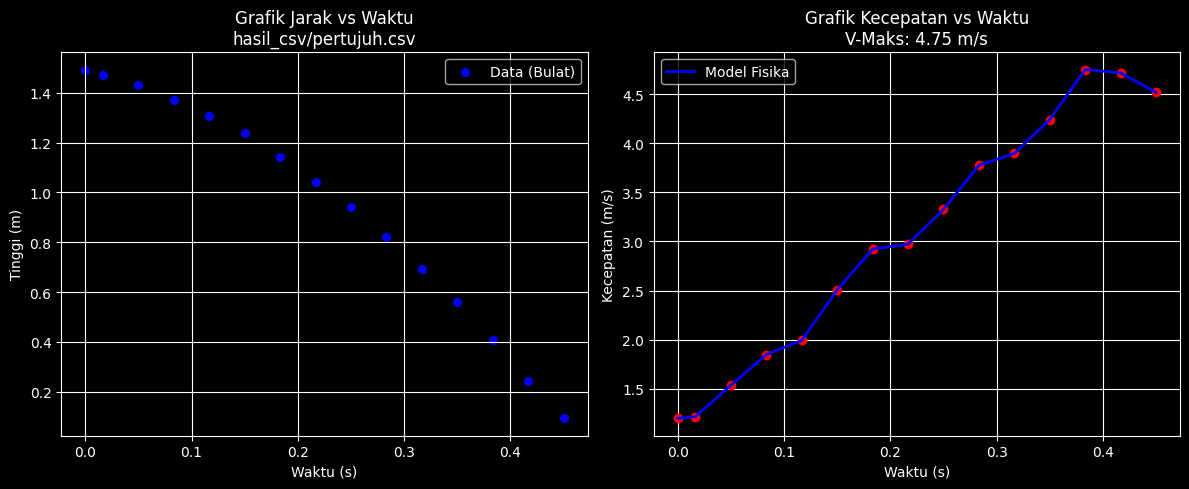

In [62]:
import matplotlib.pyplot as plt
for f in files:
    g_individu, vmax, t, y, v = calculate_g_and_v_max(f)

    plt.figure(figsize=(12, 5))

    # Jarak vs Waktu
    plt.subplot(1, 2, 1)
    plt.scatter(t, y, color='blue', s=30, label='Data (Bulat)')
    plt.title(f"Grafik Jarak vs Waktu\n{f}")
    plt.xlabel("Waktu (s)")
    plt.ylabel("Tinggi (m)")
    plt.grid(True)
    plt.legend()

    # Kecepatan vs Waktu
    plt.subplot(1, 2, 2)
    plt.plot(t, v, marker='o', color='red', linestyle='--')
    plt.plot(t, v, color='blue', linewidth=2, label='Model Fisika')
    plt.title(f"Grafik Kecepatan vs Waktu\nV-Maks: {round(vmax, 3)} m/s")
    plt.xlabel("Waktu (s)")
    plt.ylabel("Kecepatan (m/s)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"analisis_{os.path.splitext(os.path.basename(f))[0]}.png")